## ZL048 and ZR048 Geocalibrations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
from sklearn.linear_model import RANSACRegressor
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
def get_fl(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl0 + left_fl1 * fmc
  elif (data_["cam"][idx][1] == "R"):
    return right_fl0 + right_fl1 * fmc

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray,
          left_fl0:float, left_fl1:float,
          right_fl0:float, right_fl1:float)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

In [3]:
# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

  return z_data

In [4]:
f_str = "048"

data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)


zl, zr = get_zl_zr(f_str, data_all)
parse_cahvor(zl)
parse_cahvor(zr)
print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

Number of data points for zl048:	38
Number of data points for zr048:	248


In [5]:
# use plolty to plot f_est against fmc
import plotly.express as px
from plotly.subplots import make_subplots

# zl_outlier_idx = [0, 1, 24, 25, 26, 27, 28, 34, 35, 36, 37]
# zr_outlier_idx = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
#                   20,21,22,23,24,25,26,31,32,
#                   215, 216, 217, 218, 219, 220, 221,
#                   230, 231,232,234,236,238,239,240,241,242,243,244,245,246,247]
# zl_outlier_idx = [0, 1, 8, 24, 25, 26, 27, 28, 34, 35, 36, 37]
# zr_outlier_idx = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,
#                      244,245,246,247]
zl_outlier_idx = [5,6,7,8,9,10,11,21,22,23,24,25,26,27,28,29,32,33,34,35,36,37]
zr_outlier_idx = []

zl_outliers = zl.iloc[zl_outlier_idx,:]
zr_outliers = zr.iloc[zr_outlier_idx,:]

fig = make_subplots(rows=1, cols=2, subplot_titles=["ZL048", "ZR048"])

fig.add_trace(px.scatter(zl, x="fmc", y="f_est", hover_data=[zl.index]).data[0], row=1, col=1)
fig.add_trace(px.scatter(zl_outliers, x="fmc", y="f_est",
                        hover_data=[zl_outliers.index]).update_traces(marker=dict(color="red")).data[0], row=1, col=1)
fig.add_trace(px.scatter(zr, x="fmc", y="f_est", hover_data=[zr.index]).data[0], row=1, col=2)
fig.add_trace(px.scatter(zr_outliers, x="fmc", y="f_est",
                        hover_data=[zr_outliers.index]).update_traces(marker=dict(color="red")).data[0], row=1, col=2)


fig.update_layout(width=1000, height=400, title="f_est vs fmc for ZL048 and ZR048")

In [6]:
q_rrp = [5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]
# find q_mc for ZL
q_mc_data_zl = []

for i in range(zl.shape[0]):
  # q_mc from data
  R_rrp = R.from_quat(q_rrp).as_matrix()
  R_rpm = get_R_rpm(i, zl)
  Hr = get_H_r_data(i, zl)
  fl = zl["f_est"][i]
  b1,b2,cx,cy = zl["b1_est"][i], zl["b2_est"][i], zl["cx_est"][i], zl["cy_est"][i]
  Hc = np.array([[fl+b1, b2, cx],
                 [0,fl,cy],
                 [0,0,1]]).T
  R_mc_data = (R_rrp @ R_rpm).T @ Hr @ np.linalg.inv(Hc)
  q_mc_data_zl.append(R.from_matrix(R_mc_data).as_quat(canonical=True))



# find q_mc for Zr
q_mc_data_zr = []

for i in range(zr.shape[0]):
  # q_mc from data
  R_rrp = R.from_quat(q_rrp).as_matrix()
  R_rpm = get_R_rpm(i, zr)
  Hr = get_H_r_data(i, zr)
  fl = zr["f_est"][i]
  b1,b2,cx,cy = zr["b1_est"][i], zr["b2_est"][i], zr["cx_est"][i], zr["cy_est"][i]
  Hc = np.array([[fl+b1, b2, cx],
                 [0,fl,cy],
                 [0,0,1]]).T
  R_mc_data = (R_rrp @ R_rpm).T @ Hr @ np.linalg.inv(Hc)
  q_mc_data_zr.append(R.from_matrix(R_mc_data).as_quat(canonical=True))


In [7]:
fig = make_subplots(rows=1, cols=4, subplot_titles=[f"q_{i}" for i in range(4)])

zl_outliers = zl.iloc[zl_outlier_idx, :]
q_mc_outliers = [q_mc_data_zl[i] for i in zl_outlier_idx]

for i in range(4):
  q_i = [q[i] for q in q_mc_data_zl]
  fig.add_trace(px.scatter(x=zl["fmc"], y=q_i,
                          hover_data=[zl["name"], zl.index]).data[0], row=1, col=i+1)
  fig.add_trace(px.scatter(x=zl_outliers["fmc"], 
                           y=[q[i] for q in q_mc_outliers],
                           hover_data=[zl_outliers["name"], zl_outliers.index]).update_traces(marker=dict(color="red")).data[0]
                ,row=1, col=i+1)
  

fig.update_layout(height=400, width=1000, title_text="q_mc for ZL048")
fig.show()

In [8]:
fig = make_subplots(rows=1, cols=4, subplot_titles=[f"q_{i}" for i in range(4)])
# zr_outlier_idx = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,
#                   244,245,246,247]

zr_outliers = zr.iloc[zr_outlier_idx, :]
q_mc_outliers = [q_mc_data_zr[i] for i in zr_outlier_idx]

for i in range(4):
  q_i = [q[i] for q in q_mc_data_zr]
  fig.add_trace(px.scatter(x=zr["fmc"], y=q_i,
                          hover_data=[zr["name"], zr.index]).update_traces(marker=dict(color="blue")).data[0], row=1, col=i+1)
  

  # q_i_outliers = [q[i] for q in q_mc_outliers]
  # fig.add_trace(px.scatter(x=zr_outliers["fmc"], y=q_i_outliers,
  #                          hover_data=[zr_outliers["name"], zr_outliers.index]).update_traces(marker=dict(color="red")).data[0],
  #                         row=1, col=i+1)

fig.update_layout(height=400, width=1000, title_text="q_mc for ZR048")
fig.show()

In [9]:
zl = zl.drop(zl_outlier_idx).reset_index(drop=True)
zr = zr.drop(zr_outlier_idx).reset_index(drop=True)

print('-'*75)
print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

---------------------------------------------------------------------------
Number of data points for zl048:	16
Number of data points for zr048:	248


## Focal length as a function of fmc

In [10]:
# Linear least squares fit for fl vs fmc
X_l =  np.vstack([np.ones(zl["fmc"].shape[0]), zl["fmc"]]).T
X_r =  np.vstack([np.ones(zr["fmc"].shape[0]), zr["fmc"]]).T

fl_l_0, fl_l_1  = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ zl["f_est"]
res_l = (np.abs(zl["f_est"] - (fl_l_0 + fl_l_1 * zl["fmc"]))).mean()
fl_r_0, fl_r_1 = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ zr["f_est"]
res_r = (np.abs(zr["f_est"] - (fl_r_0 + fl_r_1 * zr["fmc"]))).mean()


print(f"Left:  f_est = {fl_l_0:.4f} + {fl_l_1:.4f} * fmc")
print(f"left res square error: {res_l:.4f}")
print(f"Right: f_est = {fl_r_0:.4f} + {fl_r_1:.4f} * fmc")
print(f"right res square error: {res_r:.4f}")

Left:  f_est = 6664.2423 + 0.0011 * fmc
left res square error: 5.6034
Right: f_est = 6589.6131 + 0.0342 * fmc
right res square error: 10.6554


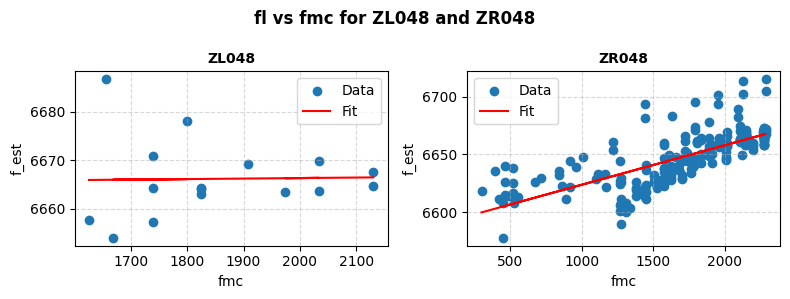

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

for i, (d, fl_0, fl_1) in enumerate(zip([zl, zr], [fl_l_0, fl_r_0], [fl_l_1, fl_r_1])):
    ax[i].scatter(d["fmc"], d["f_est"], label="Data")
    ax[i].plot(d["fmc"], fl_0 + fl_1 * d["fmc"], label="Fit", color="red")
    ax[i].set_xlabel("fmc")
    ax[i].set_ylabel("f_est")
    ax[i].set_title(f"ZL{f_str}" if i==0 else f"ZR{f_str}",
                    fontweight="bold", fontsize=10)
    ax[i].legend()
    ax[i].grid(linestyle="--", alpha=0.5)

fig.suptitle(f"fl vs fmc for ZL{f_str} and ZR{f_str}", fontweight="bold", fontsize=12)
fig.tight_layout()

## Rotation Fitting

In [30]:
from typing import List

def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)
  
  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)
  # return np.sqrt(np.linalg.norm(q1 - q2)**2)

def gen_rot_obj(data_:pd.DataFrame)->callable:
  data__ = data_.copy()
  q_rrp = [5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]

  def rot_obj(x_:List):
  
    assert len(x_) == 8

    total_cost = 0
    count = 0
    for i in range(data__.shape[0]):
      # calc rotation from model
      f = data__["fmc"][i]
      rot_mc_0 = R.from_quat(x_[:4])
      rot_mc_1 = R.from_quat(x_[4:8])
      rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))
      q_mc_model = rot_mc_model.as_quat(canonical=True)

      # calc rotation from data
      fl = data__["f_est"][i]
      b1,b2 = data__["b1_est"][i], data__["b2_est"][i]
      cx, cy = data__["cx_est"][i], data_["cy_est"][i]
      Hc_inv =  np.array([[1/(fl+b1), 0, 0],
              [-b2/(fl*(fl+b1)),1/fl,0],
              [((cy*b2)/(fl*(fl+b1)))-(cx/(fl+b1)),-cy/fl,1]])

      rot_rrp = R.from_quat(q_rrp)
      rot_rpm = R.from_matrix(data__["R_rpm_mat"][i])
      Hr = get_H_r_data(i, data__)

      rot_mc_data = (rot_rrp * rot_rpm).as_matrix().T @ Hr @ Hc_inv
      q_mc_data = R.from_matrix(rot_mc_data).as_quat(canonical=True)

      # calc and add to total cost
      total_cost += dist_q(q_mc_data, q_mc_model)
      count += 1

    
    return (total_cost/count)
  
  return rot_obj

In [31]:
# data = pd.concat([zl, zr], axis=0).reset_index(drop=True)
left_rot_obj = gen_rot_obj(zl)
x0_left = [0.44, 0.56, 0.50, 0.491,
          0.01, 0.01, 0.01, 1]

left_res = minimize(left_rot_obj, x0_left, method="BFGS", 
               options={"gtol":1e-20, "xrtol":1e-20,"maxiter":200})

right_rot_obj = gen_rot_obj(zr)
x0_right = [0.4785, 0.467, 0.530, 0.5215,
           0.01, 0.01, 0.01, 1]

right_res = minimize(right_rot_obj, x0_right, method="BFGS", 
               options={"gtol":1e-20, "xrtol":1e-20,"maxiter":200})

In [32]:
# q_rrp = np.array(res.x[:4])
q_rrp = [5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]
q_cm_zl_0 = np.array(left_res.x[0:4])/np.linalg.norm(left_res.x[0:4])
# q_cm_zl_0 = np.array(left_res.x[0:4])
q_cm_zl_1 = np.array(left_res.x[4:8])

q_cm_zr_0 = np.array(right_res.x[0:4])/np.linalg.norm(right_res.x[0:4])
# q_cm_zr_0 = np.array(right_res.x[0:4])
q_cm_zr_1 = np.array(right_res.x[4:8])

print(f"Left Final function:{left_res.fun:.6f}")
print(f"Left Final Jacobian:{np.linalg.norm(left_res.jac):.6f}")
print(f"Right Final function:{right_res.fun:.6f}")
print(f"Right Final Jacobian:{np.linalg.norm(right_res.jac):.6f}")

# print(f"q_rrp:{q_rrp}")
print(f"q_cm_zl_0:{q_cm_zl_0}")
print(f"q_cm_zl_1:{q_cm_zl_1}")
print(f"q_cm_zr_0:{q_cm_zr_0}")
print(f"q_cm_zr_1:{q_cm_zr_1}")

# rot_cm_zl_1_deg = R.from_quat(q_cm_zl_1).as_euler("xyz", degrees=True)
# rot_cm_zr_1_deg = R.from_quat(q_cm_zr_1).as_euler("xyz", degrees=True)
# print(f"rot_cm_zl_1_deg:{rot_cm_zl_1_deg}")
# print(f"rot_cm_zr_1_deg:{rot_cm_zr_1_deg}")

Left Final function:0.001172
Left Final Jacobian:0.001921
Right Final function:0.001736
Right Final Jacobian:0.000296
q_cm_zl_0:[0.44377992 0.5625695  0.49968724 0.48671101]
q_cm_zl_1:[-2.32039184e-03 -7.76827219e-04 -1.64998431e-03  9.99950642e-01]
q_cm_zr_0:[0.47836347 0.46744645 0.53026443 0.5210392 ]
q_cm_zr_1:[-2.41929644e-04 -7.25081136e-05 -1.41122889e-04  1.00542224e+00]


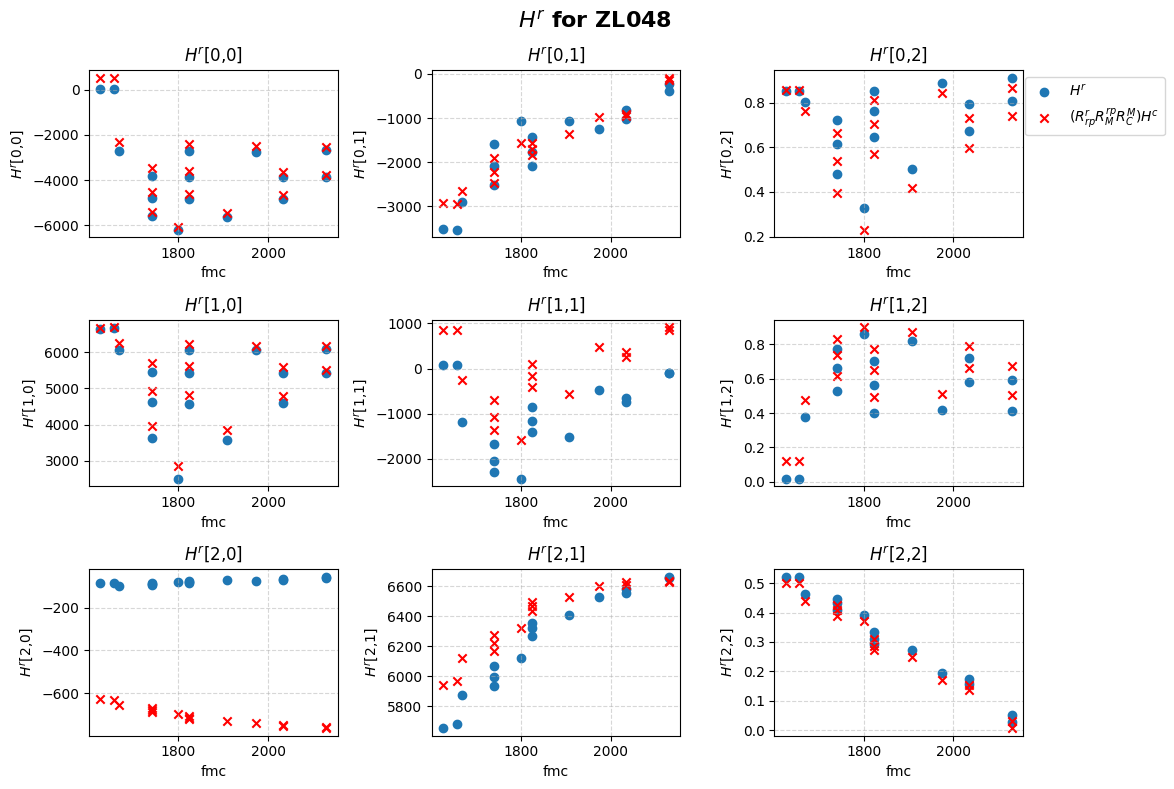

In [33]:
Hr_data_zl = []
Hr_model_zl = []
q_rrp = [5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]

for i in range(zl.shape[0]):
  # data
  Hr_data_zl.append(get_H_r_data(i, zl))

  # model
  rot_rrp = R.from_quat(q_rrp)
  rot_rpm = R.from_matrix(get_R_rpm(i, zl))
  
  fl = zl["f_est"][i]
  b1,b2 = zl["b1_est"][i], zl["b2_est"][i]
  cx, cy = zl["cx_est"][i], zl["cy_est"][i]

  Hc = np.array([[fl+b1, b2, cx],
              [0,fl,cy],
              [0,0,1]]).T

  f = zl["fmc"][i]
  rot_mc_0 = R.from_quat(q_cm_zl_0)
  rot_mc_1 = R.from_quat(q_cm_zl_1)
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
  rot_rc = rot_rrp * rot_rpm * rot_mc


  Hr_model_zl.append(rot_rc.as_matrix() @ Hc)

# plot
fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl["fmc"], [H[r,c] for H in Hr_data_zl], label="expectation")
    ax[r,c].scatter(zl["fmc"], [H[r, c] for H in Hr_model_zl], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")
    ax[r,c].set_xlabel("fmc")
    ax[r,c].set_ylabel(f"$H^r$[{r},{c}]")
    ax[r,c].grid(linestyle="--", alpha=0.5)

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) H^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle(f"$H^r$ for ZL{f_str}", fontsize=16, fontweight="bold")
fig.tight_layout()

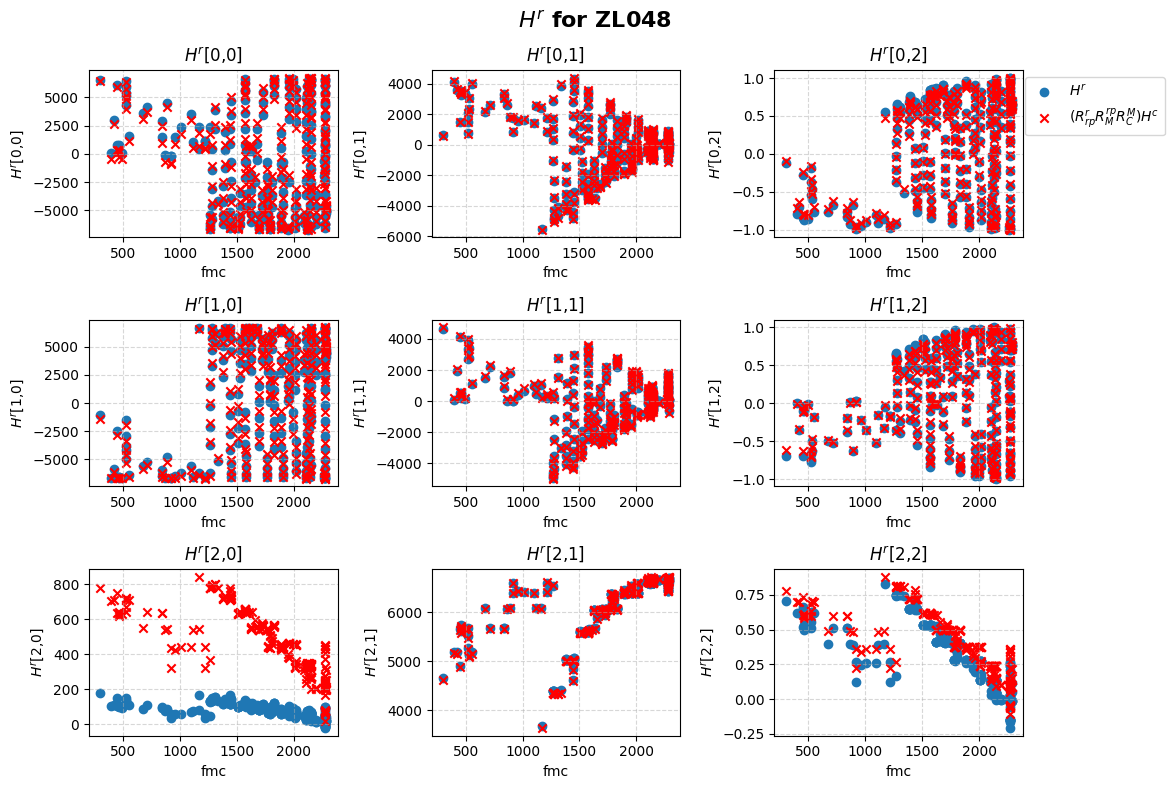

In [34]:
Hr_data_zr = []
Hr_model_zr = []

for i in range(zr.shape[0]):
  # data
  Hr_data_zr.append(get_H_r_data(i, zr))

  # model
  rot_rrp = R.from_quat(q_rrp)
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  fl = zr["f_est"][i]
  b1,b2 = zr["b1_est"][i], zr["b2_est"][i]
  cx, cy = zr["cx_est"][i], zr["cy_est"][i]

  Hc = np.array([[fl+b1, b2, cx],
              [0,fl,cy],
              [0,0,1]]).T
  
  f = zr["fmc"][i]
  rot_mc_0 = R.from_quat(q_cm_zr_0)
  rot_mc_1 = R.from_quat(q_cm_zr_1)
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
  rot_rc = rot_rrp * rot_rpm * rot_mc
  Hr_model_zr.append(rot_rc.as_matrix() @ Hc)

# plot
fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr["fmc"], [H[r,c] for H in Hr_data_zr], label="expectation")
    ax[r,c].scatter(zr["fmc"], [H[r, c] for H in Hr_model_zr], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")
    ax[r,c].set_xlabel("fmc")
    ax[r,c].set_ylabel(f"$H^r$[{r},{c}]")
    ax[r,c].grid(linestyle="--", alpha=0.5)

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) H^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle(f"$H^r$ for ZL{f_str}", fontsize=16, fontweight="bold")
fig.tight_layout()

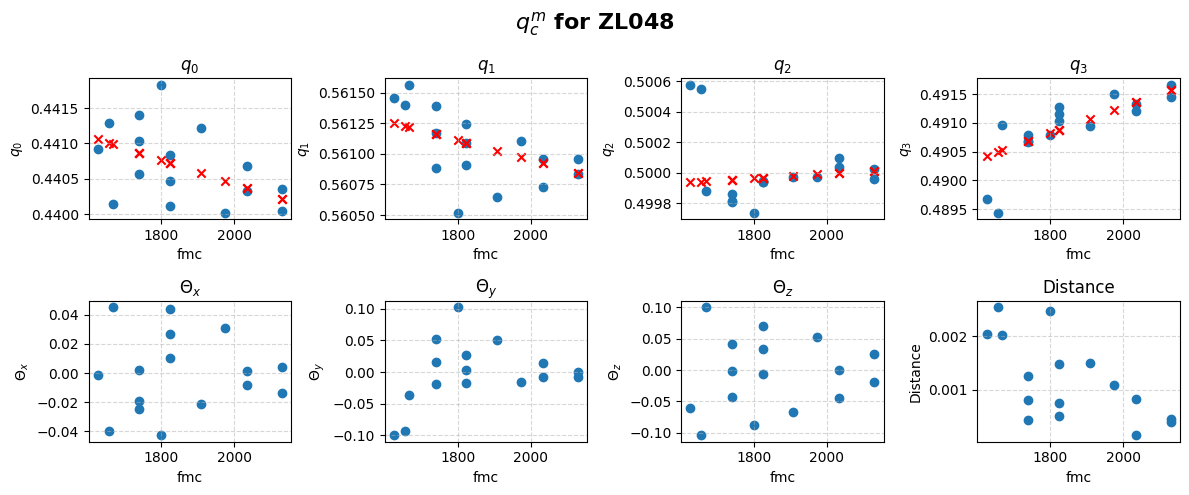

In [41]:
q_mc_model_zl = []
q_mc_data_zl = []
delta_dist_zl = []
delta_angle_zl = []

for i in range(zl.shape[0]):
  # q_mc from data
  R_rrp = R.from_quat(q_rrp).as_matrix()
  R_rpm = get_R_rpm(i, zl)
  Hr = get_H_r_data(i, zl)
  
  fl = zl["f_est"][i] 
  b1,b2 = zl["b1_est"][i], zl["b2_est"][i]
  cx, cy = zl["cx_est"][i], zl["cy_est"][i]

  Hc = np.array([[fl+b1, b2, cx],
              [0,fl,cy],
              [0,0,1]]).T

  R_mc_data = (R_rrp @ R_rpm).T @ Hr @ np.linalg.inv(Hc)
  q_mc_data_ = R.from_matrix(R_mc_data).as_quat(canonical=True)
  q_mc_data_zl.append(q_mc_data_)

  # q_mc from model
  rot_mc_0 = R.from_quat(q_cm_zl_0)
  rot_mc_1 = R.from_quat(q_cm_zl_1)
  f = zl["fmc"][i]
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
  q_mc_model_ = rot_mc.as_quat(canonical=True)
  q_mc_model_zl.append(q_mc_model_)

  delta_dist_zl.append(dist_q(q_mc_data_, q_mc_model_))
  delta_rot = R.from_quat(q_mc_data_).inv() * R.from_quat(q_mc_model_)
  delta_angle_zl.append(delta_rot.as_euler("xyz", degrees=True))

# plot
fig, ax = plt.subplots(2, 4, figsize=(12,5))

for i in range(4):
  ax[0,i].scatter(zl["fmc"], [q[i] for q in q_mc_data_zl], label="expectation")
  ax[0,i].scatter(zl["fmc"], [q[i] for q in q_mc_model_zl], color="red", marker='x', label="model")
  ax[0,i].set_title(f"$q_{i}$")
  ax[0,i].set_xlabel("fmc")
  ax[0,i].set_ylabel(f"$q_{i}$")
  ax[0,i].grid(linestyle="--", alpha=0.5)

for i, angle in enumerate(["x", "y", "z"]):
  ax[1,i].scatter(zl["fmc"], [angle[i] for angle in delta_angle_zl])
  ax[1,i].set_title(f"$\Theta_{angle}$")
  ax[1,i].set_xlabel("fmc")
  ax[1,i].set_ylabel(f"$\Theta_{angle}$")
  ax[1,i].grid(linestyle="--", alpha=0.5)

ax[1,3].scatter(zl["fmc"], delta_dist_zl)
ax[1,3].set_title("Distance")
ax[1,3].set_xlabel("fmc")
ax[1,3].set_ylabel("Distance")
ax[1,3].grid(linestyle="--", alpha=0.5)

fig.suptitle(f"$q^m_c$ for ZL{f_str}", fontsize=16, fontweight="bold")
fig.tight_layout()

In [19]:
import plotly.express as px
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=4, subplot_titles=[f"q_{i}" for i in range(4)], 
                    )

for i in range(4):
  q_i = [q[i] for q in q_mc_data_zl]
  fig.add_trace(px.scatter(x=zl["fmc"], y=q_i,
                          hover_data=[zl["name"], zl.index]).data[0], row=1, col=i+1)

fig.update_layout(height=400, width=1000, title_text="q_mc for ZL048")
fig.show()


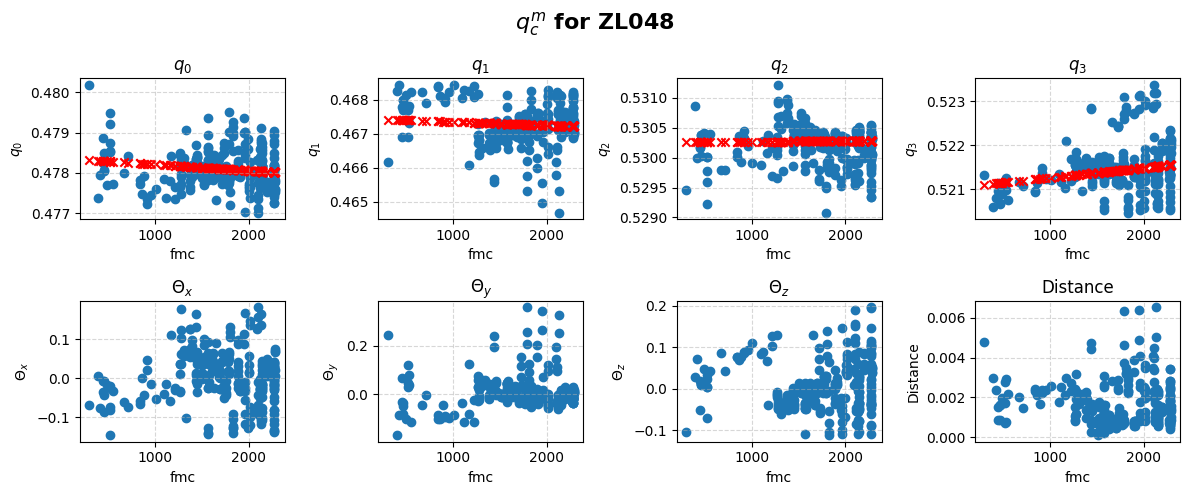

In [42]:
q_mc_model_zr = []
q_mc_data_zr = []
delta_dist_zr = []
delta_angle_zr = []

for i in range(zr.shape[0]):
  # q_mc from data
  R_rrp = R.from_quat(q_rrp).as_matrix()
  R_rpm = get_R_rpm(i, zr)
  Hr = get_H_r_data(i, zr)
  
  fl = zr["f_est"][i] 
  b1,b2 = zr["b1_est"][i], zr["b2_est"][i]
  cx, cy = zr["cx_est"][i], zr["cy_est"][i]

  Hc = np.array([[fl+b1, b2, cx],
              [0,fl,cy],
              [0,0,1]]).T

  R_mc_data = (R_rrp @ R_rpm).T @ Hr @ np.linalg.inv(Hc)
  q_mc_data_ = R.from_matrix(R_mc_data).as_quat(canonical=True)
  q_mc_data_zr.append(q_mc_data_)

  # q_mc from model
  rot_mc_0 = R.from_quat(q_cm_zr_0)
  rot_mc_1 = R.from_quat(q_cm_zr_1)
  f = zr["fmc"][i]
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
  q_mc_model_ = rot_mc.as_quat(canonical=True)
  q_mc_model_zr.append(q_mc_model_)

  delta_dist_zr.append(dist_q(q_mc_data_, q_mc_model_))
  delta_rot = R.from_quat(q_mc_data_).inv() * R.from_quat(q_mc_model_)
  delta_angle_zr.append(delta_rot.as_euler("xyz", degrees=True))

# plot
fig, ax = plt.subplots(2, 4, figsize=(12,5))

for i in range(4):
  ax[0,i].scatter(zr["fmc"], [q[i] for q in q_mc_data_zr], label="expectation")
  ax[0,i].scatter(zr["fmc"], [q[i] for q in q_mc_model_zr], color="red", marker='x', label="model")
  ax[0,i].set_title(f"$q_{i}$")
  ax[0,i].set_xlabel("fmc")
  ax[0,i].set_ylabel(f"$q_{i}$")
  ax[0,i].grid(linestyle="--", alpha=0.5)

for i, angle in enumerate(["x", "y", "z"]):
  ax[1,i].scatter(zr["fmc"], [angle[i] for angle in delta_angle_zr])
  ax[1,i].set_title(f"$\Theta_{angle}$")
  ax[1,i].set_xlabel("fmc")
  ax[1,i].set_ylabel(f"$\Theta_{angle}$")
  ax[1,i].grid(linestyle="--", alpha=0.5)

ax[1,3].scatter(zr["fmc"], delta_dist_zr)
ax[1,3].set_title("Distance")
ax[1,3].set_xlabel("fmc")
ax[1,3].set_ylabel("Distance")
ax[1,3].grid(linestyle="--", alpha=0.5)

fig.suptitle(f"$q^m_c$ for ZL{f_str}", fontsize=16, fontweight="bold")
fig.tight_layout()

In [21]:
import plotly.express as px
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=4, subplot_titles=[f"q_{i}" for i in range(4)])
# zr_outlier_idx = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,
#                   244,245,246,247]

zr_outliers = zr.iloc[zr_outlier_idx, :]
q_mc_outliers = [q_mc_data_zr[i] for i in zr_outlier_idx]

for i in range(4):
  q_i = [q[i] for q in q_mc_data_zr]
  fig.add_trace(px.scatter(x=zr["fmc"], y=q_i,
                          hover_data=[zr["name"], zr.index]).update_traces(marker=dict(color="blue")).data[0], row=1, col=i+1)
  

  # q_i_outliers = [q[i] for q in q_mc_outliers]
  # fig.add_trace(px.scatter(x=zr_outliers["fmc"], y=q_i_outliers,
  #                          hover_data=[zr_outliers["name"], zr_outliers.index]).update_traces(marker=dict(color="red")).data[0],
  #                         row=1, col=i+1)

fig.update_layout(height=400, width=1000, title_text="q_mc for ZR048")
fig.show()


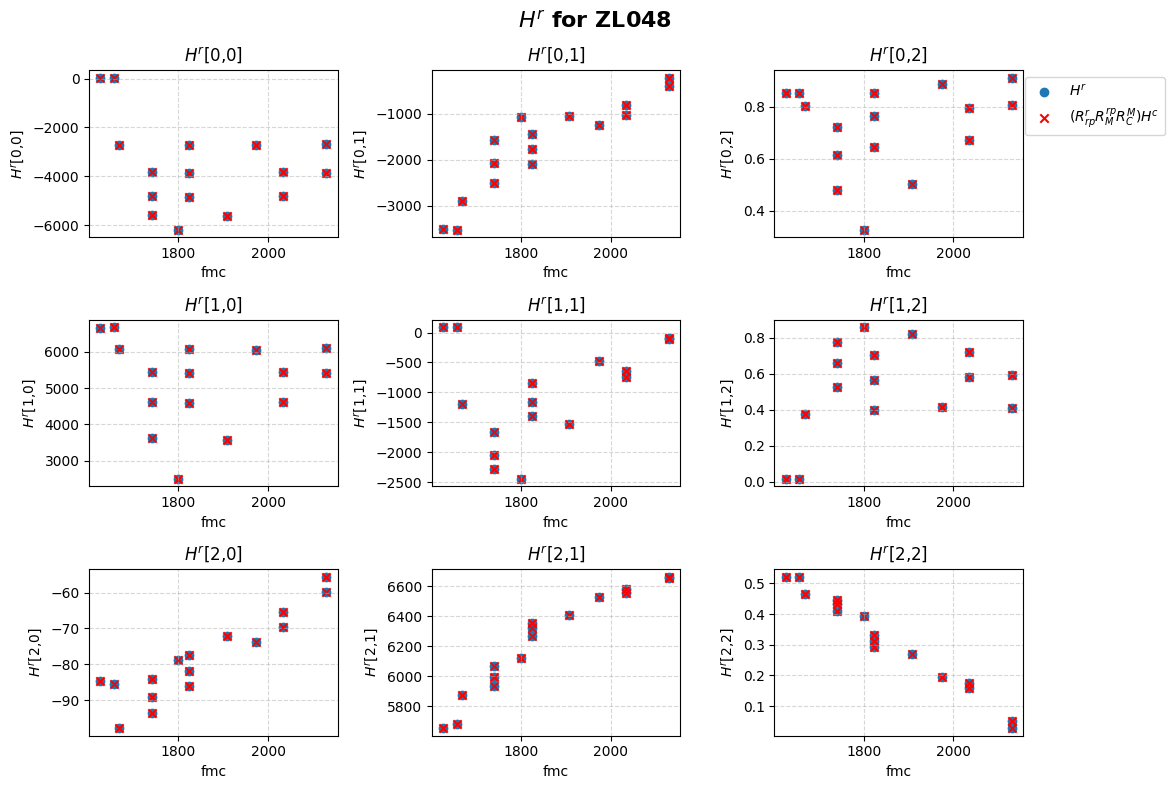

In [37]:
Hr_data_zl = []
Hr_model_zl = []
q_rrp = [5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]

for i in range(zl.shape[0]):
  # data
  Hr_data_zl.append(get_H_r_data(i, zl))


  # model
  rot_rrp = R.from_quat(q_rrp)
  rot_rpm = R.from_matrix(get_R_rpm(i, zl))
  
  fl = zl["f_est"][i]
  b1,b2 = zl["b1_est"][i], zl["b2_est"][i]
  cx, cy = zl["cx_est"][i], zl["cy_est"][i]

  Hc = np.array([[fl+b1, 0, 0],
                 [b2, fl, 0],
                 [cx, cy, 1]])
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
              [-b2/(fl*(fl+b1)),1/fl,0],
              [((cy*b2)/(fl*(fl+b1)))-(cx/(fl+b1)),-cy/fl,1]])
  

  Hr = get_H_r_data(i, zl)
  R_mc = (rot_rrp * rot_rpm).as_matrix().T @ Hr @ Hc_inv

  Hr_model = (rot_rrp * rot_rpm).as_matrix() @ R_mc @ Hc


  Hr_model_zl.append(Hr_model) 

# plot
fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl["fmc"], [H[r,c] for H in Hr_data_zl], label="expectation")
    ax[r,c].scatter(zl["fmc"], [H[r, c] for H in Hr_model_zl], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")
    ax[r,c].set_xlabel("fmc")
    ax[r,c].set_ylabel(f"$H^r$[{r},{c}]")
    ax[r,c].grid(linestyle="--", alpha=0.5)

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) H^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle(f"$H^r$ for ZL{f_str}", fontsize=16, fontweight="bold")
fig.tight_layout()